# Explore plights.pkl

New set of HESE depth-dependent P_light functions.

**Functional form** — 5 parameters per depth slice:
```
modified_sigmoid(E_mu, k0, x0, k1, x1, c)
    = 1 / (1 + exp(-k0*(log10(E_mu) - x0)))   ← sigmoid
    + c * exp(-(log10(E_mu) - x1)^2 / k1)      ← Gaussian bump
```

Unlike the old 3-parameter `sigmoid_Tianlu`, this goes to **0 at low muon energies**
(no floor), which is more physically correct.

Keys are **z-coordinates** (z = 1948 − depth_m), matching the convention in
`nuveto_cluster_script.py`.

In [3]:
import sys
sys.path = [p for p in sys.path if "rnaab" not in p]

import os
import re
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

PKL      = "/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/unblind/passing_fraction/plights_tianlu/plights.pkl"
OLD_PL_PY = "/home/rnaab/software/virtualenvs/nuveto/lib/python3.6/site-packages/nuVeto/resources/mu/pl.py"
PLOTS_DIR = os.path.join(os.path.dirname(PKL), "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

with open(PKL, "rb") as fh:
    raw = pickle.load(fh, encoding='latin1')

# Sort by z, convert to depth_m
entries = sorted(
    [{"z": z, "depth_m": 1948.0 - z, "params": p} for z, p in raw.items()],
    key=lambda e: e["depth_m"]
)

depths_m = np.array([e["depth_m"] for e in entries])
z_coords = np.array([e["z"]       for e in entries])

print(f"Entries:     {len(entries)}")
print(f"Depth range: {depths_m.min():.1f} – {depths_m.max():.1f} m")
print(f"z spacing:   {np.diff(z_coords[::-1]).mean():.2f} m  (regular: {np.allclose(np.diff(z_coords[::-1]), np.diff(z_coords[::-1])[0])})")
print(f"Params shape: {entries[0]['params'].shape}  → (k0, x0, k1, x1, c)")
print()
print("Sample entry (mid depth):")
mid = entries[len(entries)//2]
print(f"  depth={mid['depth_m']:.1f} m, z={mid['z']:.3f}")
print(f"  k0={mid['params'][0]:.4f}, x0={mid['params'][1]:.4f}, "
      f"k1={mid['params'][2]:.4f}, x1={mid['params'][3]:.4f}, c={mid['params'][4]:.4f}")

Entries:     50
Depth range: 1423.0 – 2461.0 m
z spacing:   21.18 m  (regular: True)
Params shape: (5,)  → (k0, x0, k1, x1, c)

Sample entry (mid depth):
  depth=1952.6 m, z=-4.592
  k0=2.1735, x0=3.1178, k1=1.8220, x1=2.1444, c=0.5919


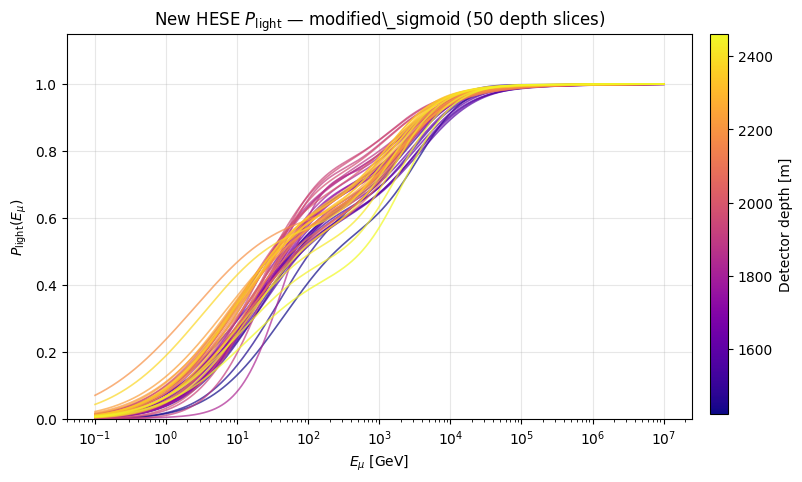

In [4]:
def modified_sigmoid(emu, k0, x0, k1, x1, c):
    """P_light(E_mu): sigmoid + Gaussian bump, goes to 0 at low E."""
    x = np.log10(np.asarray(emu, dtype=float))
    return 1/(1 + np.exp(-k0*(x - x0))) + c*np.exp(-(x - x1)**2 / k1)

E_mu = np.logspace(-1, 7, 800)   # 0.1 GeV – 10 PeV
cmap = cm.plasma
norm = plt.Normalize(depths_m.min(), depths_m.max())

fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(right=0.82)
cax = fig.add_axes([0.84, 0.12, 0.02, 0.76])

for e in entries:
    plight = modified_sigmoid(E_mu, *e["params"])
    ax.plot(E_mu, plight, color=cmap(norm(e["depth_m"])), alpha=0.7, lw=1.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="Detector depth [m]")

ax.set_xscale("log")
ax.set_xlabel(r"$E_\mu$ [GeV]")
ax.set_ylabel(r"$P_{\rm light}(E_\mu)$")
ax.set_ylim(0, 1.15)
ax.set_title(r"New HESE $P_{\rm light}$ — modified\_sigmoid (50 depth slices)")
ax.grid(True, alpha=0.3)

plt.savefig(os.path.join(PLOTS_DIR, "plights_all_depths.pdf"), bbox_inches="tight")
plt.show()

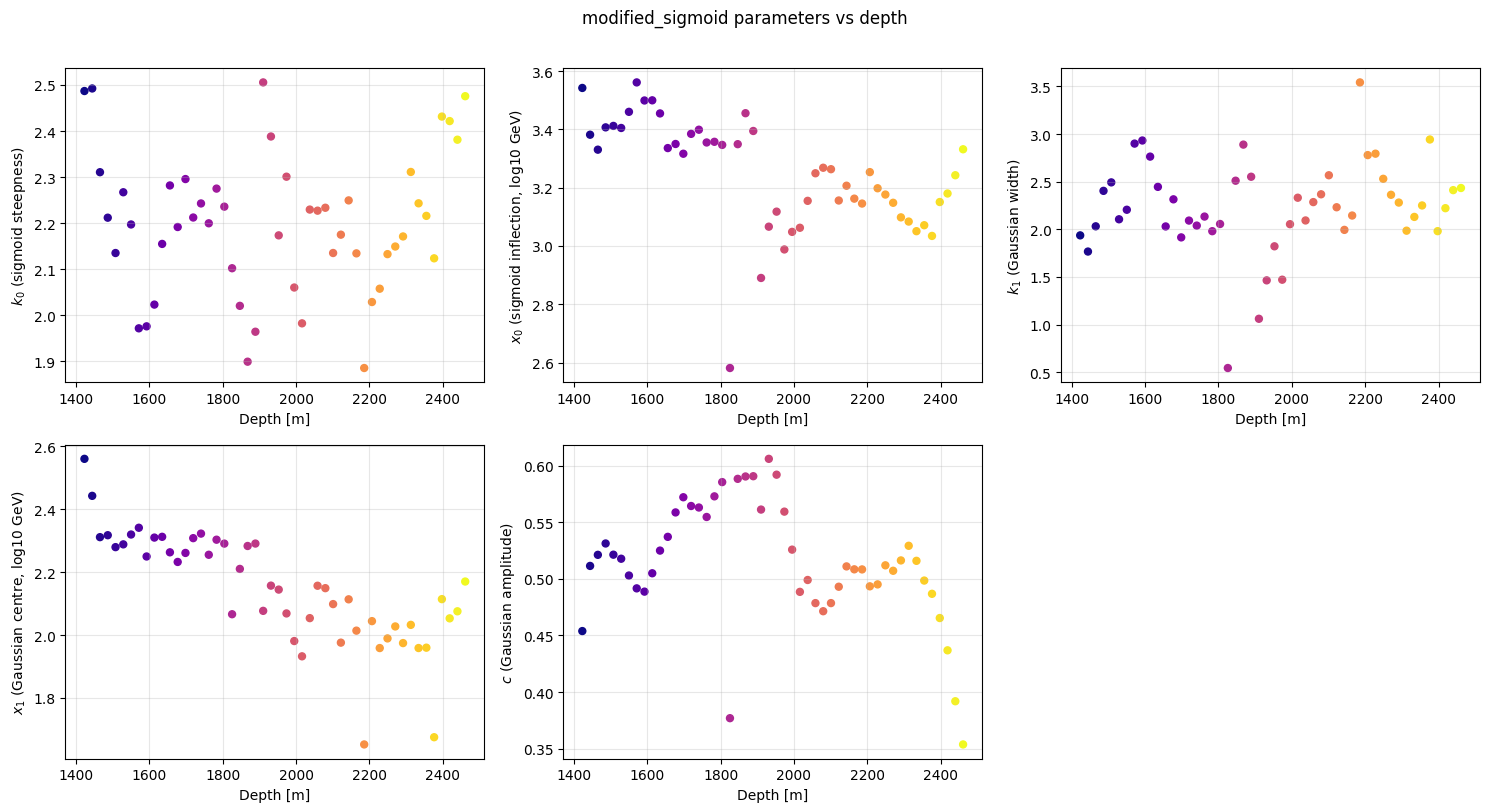

In [5]:
# Five parameters vs depth
params_arr = np.array([e["params"] for e in entries])
param_names = [r"$k_0$ (sigmoid steepness)",
               r"$x_0$ (sigmoid inflection, log10 GeV)",
               r"$k_1$ (Gaussian width)",
               r"$x_1$ (Gaussian centre, log10 GeV)",
               r"$c$ (Gaussian amplitude)"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
sc_kw = dict(s=25, c=depths_m, cmap=cmap)

for i, (name, ax) in enumerate(zip(param_names, axes)):
    ax.scatter(depths_m, params_arr[:, i], **sc_kw)
    ax.set_xlabel("Depth [m]")
    ax.set_ylabel(name)
    ax.grid(True, alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle("modified_sigmoid parameters vs depth", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plights_parameters.pdf"), bbox_inches="tight")
plt.show()

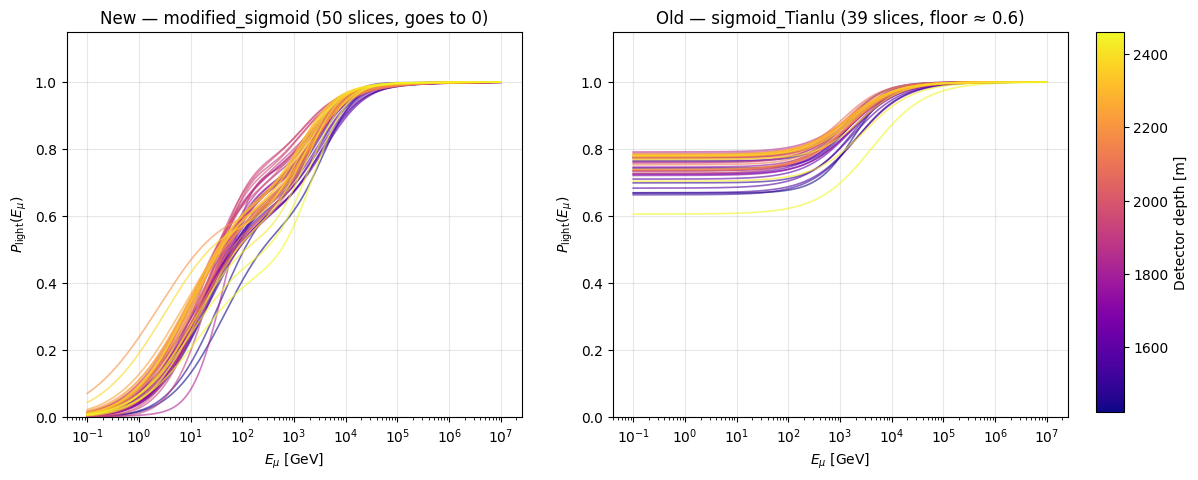

In [6]:
# Compare new (modified_sigmoid) vs old (sigmoid_Tianlu from pl.py)
# Parse old parameters from pl.py text
def sigmoid_Tianlu(emu, k0, x0, c):
    return (1 - c) / (1 + np.exp(-k0*(np.log10(emu) - x0))) + c

with open(OLD_PL_PY) as fh:
    src = fh.read()

old_entries = []
for m in re.finditer(
    r"def pl_hese_depth_(\w+)\(emu\):.*?sigmoid_Tianlu\(emu,"
    r"([\d.eE+\-]+),([\d.eE+\-]+),([\d.eE+\-]+)\)",
    src, re.DOTALL
):
    suffix = m.group(1)
    z = -int(suffix[5:]) if suffix.startswith("minus") else int(suffix)
    old_entries.append({"depth_m": 1948.0 - z,
                        "params": (float(m.group(2)), float(m.group(3)), float(m.group(4)))})
old_entries.sort(key=lambda e: e["depth_m"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.subplots_adjust(right=0.84)
cax = fig.add_axes([0.86, 0.12, 0.02, 0.76])

for e in entries:
    color = cmap(norm(e["depth_m"]))
    axes[0].plot(E_mu, modified_sigmoid(E_mu, *e["params"]), color=color, alpha=0.6, lw=1.2)

for e in old_entries:
    color = cmap(norm(e["depth_m"]))
    axes[1].plot(E_mu, sigmoid_Tianlu(E_mu, *e["params"]),   color=color, alpha=0.6, lw=1.2)

sm.set_array([])
fig.colorbar(sm, cax=cax, label="Detector depth [m]")

for ax, title in zip(axes, ["New — modified_sigmoid (50 slices, goes to 0)",
                              "Old — sigmoid_Tianlu (39 slices, floor ≈ 0.6)"]):
    ax.set_xscale("log")
    ax.set_xlabel(r"$E_\mu$ [GeV]")
    ax.set_ylabel(r"$P_{\rm light}(E_\mu)$")
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.savefig(os.path.join(PLOTS_DIR, "plights_new_vs_old.pdf"), bbox_inches="tight")
plt.show()

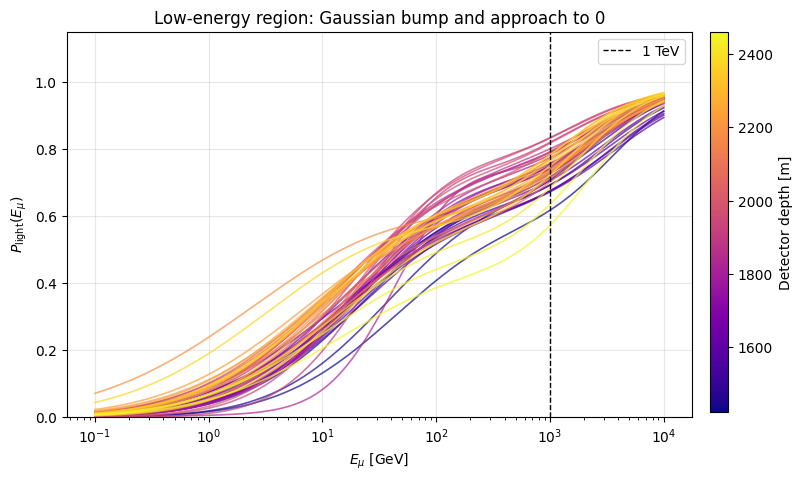

In [7]:
# Low-energy behaviour: confirm it goes to 0, and show the Gaussian bump
E_low = np.logspace(-1, 4, 500)

fig, ax = plt.subplots(figsize=(9, 5))
fig.subplots_adjust(right=0.82)
cax2 = fig.add_axes([0.84, 0.12, 0.02, 0.76])

for e in entries:
    plight = modified_sigmoid(E_low, *e["params"])
    ax.plot(E_low, plight, color=cmap(norm(e["depth_m"])), alpha=0.7, lw=1.2)

fig.colorbar(sm, cax=cax2, label="Detector depth [m]")

ax.set_xscale("log")
ax.set_xlabel(r"$E_\mu$ [GeV]")
ax.set_ylabel(r"$P_{\rm light}(E_\mu)$")
ax.set_ylim(0, 1.15)
ax.set_title("Low-energy region: Gaussian bump and approach to 0")
ax.axvline(1e3, color='k', ls='--', lw=1, label="1 TeV")
ax.legend()
ax.grid(True, alpha=0.3)

plt.savefig(os.path.join(PLOTS_DIR, "plights_low_energy.pdf"), bbox_inches="tight")
plt.show()

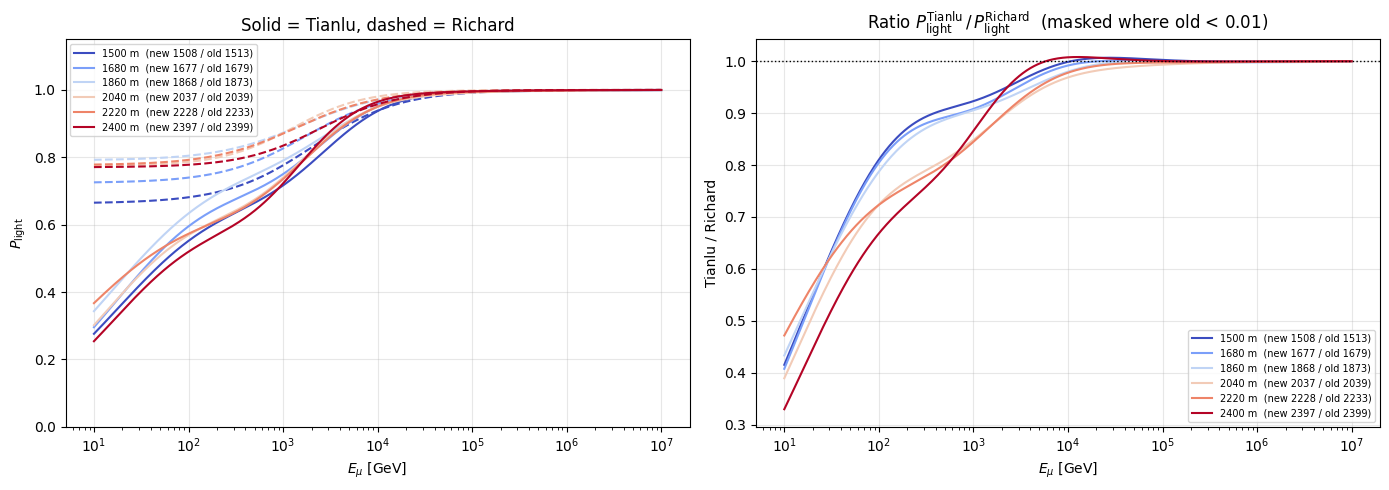

In [8]:
# Ratio new / old at a subsample of depths
# For each target depth, pick the nearest slice from each set.
# Avoid dividing at very low energies where the old floor makes the ratio diverge.

target_depths = np.linspace(1500, 2400, 6)  # 6 representative depths

old_depths = np.array([e["depth_m"] for e in old_entries])
new_depths = depths_m

tab_cmap = cm.coolwarm
tab_norm = plt.Normalize(target_depths.min(), target_depths.max())

E_ratio = np.logspace(1, 7, 600)   # 10 GeV – 10 PeV

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for d_target in target_depths:
    i_new = np.argmin(np.abs(new_depths - d_target))
    i_old = np.argmin(np.abs(old_depths - d_target))

    e_new  = entries[i_new]
    e_old  = old_entries[i_old]
    label  = f"{d_target:.0f} m  (new {e_new['depth_m']:.0f} / old {e_old['depth_m']:.0f})"
    color  = tab_cmap(tab_norm(d_target))

    pnew = modified_sigmoid(E_ratio, *e_new["params"])
    pold = sigmoid_Tianlu(E_ratio,   *e_old["params"])

    axes[0].plot(E_ratio, pnew, color=color, lw=1.5, label=label)
    axes[0].plot(E_ratio, pold, color=color, lw=1.5, ls='--')

    # Mask where old < 0.01 to avoid dividing by the low-energy floor
    mask  = pold > 0.01
    ratio = np.where(mask, pnew / pold, np.nan)
    axes[1].plot(E_ratio, ratio, color=color, lw=1.5, label=label)

axes[0].set_xscale('log')
axes[0].set_xlabel(r"$E_\mu$ [GeV]")
axes[0].set_ylabel(r"$P_{\rm light}$")
axes[0].set_ylim(0, 1.15)
axes[0].set_title("Solid = Tianlu, dashed = Richard")
axes[0].legend(fontsize=7, loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(1, color='k', lw=1, ls=':')
axes[1].set_xscale('log')
axes[1].set_xlabel(r"$E_\mu$ [GeV]")
axes[1].set_ylabel("Tianlu / Richard")
axes[1].set_title(r"Ratio $P_{\rm light}^{\rm Tianlu}\,/\,P_{\rm light}^{\rm Richard}$  (masked where old < 0.01)")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plights_ratio_new_over_old.pdf"), bbox_inches="tight")
plt.show()

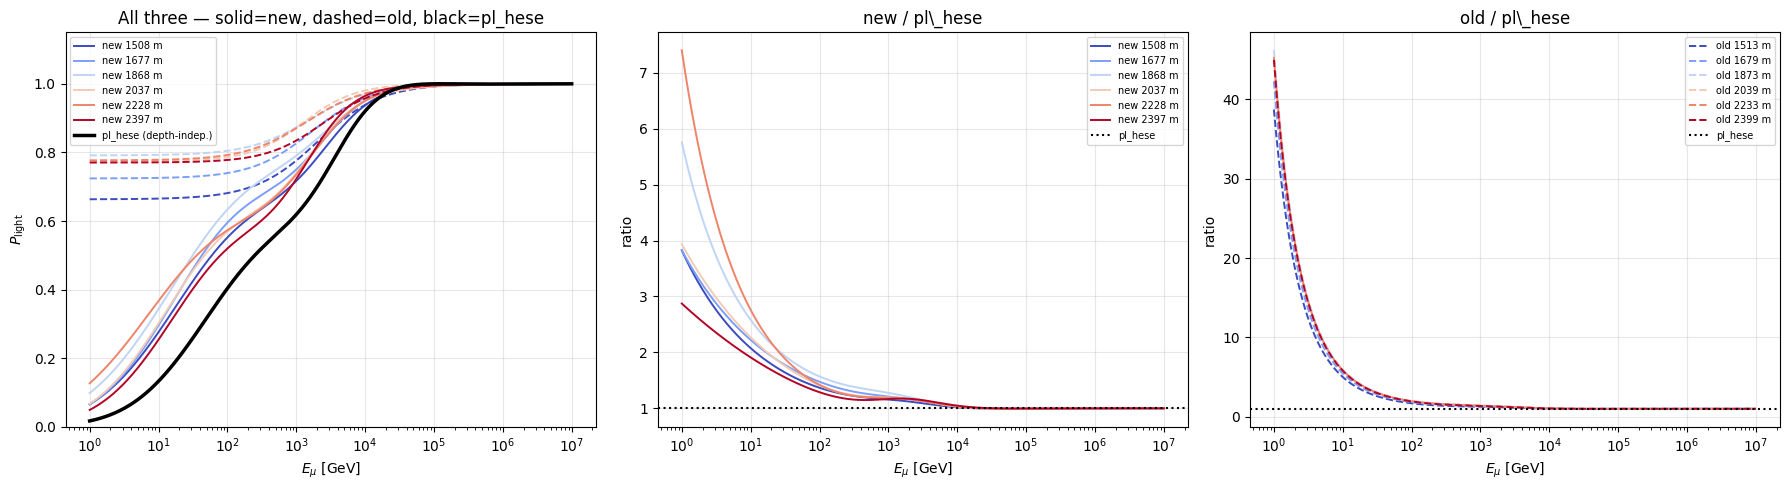

In [9]:
# Compare all three P_light families against pl_hese — a single depth-independent
# reference function from nuVeto/resources/mu/pl.py:
#
#   pl_hese(emu) = modified_sigmoid(emu, 2.48, 3.57, 2.06, 2.60, 0.458)
#                  × sigmoid(emu, center=1, scale=1e-6)
#
# sigmoid(emu, center=1, scale=1e-6) is scipy.stats.norm.cdf with near-zero
# scale — a perfect Heaviside step at 1 GeV. np.heaviside is exact here.

def pl_hese(emu):
    step = np.heaviside(np.asarray(emu, float) - 1.0, 1.0)   # step at 1 GeV
    return (modified_sigmoid(emu, 2.48135679, 3.57243996, 2.05736124, 2.60328639, 0.45801598)
            * step)

# ── subsample of 6 depths ────────────────────────────────────────────────────
E_cmp = np.logspace(0, 7, 600)   # 1 GeV – 10 PeV
ref   = pl_hese(E_cmp)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for d_target, color in zip(target_depths, [tab_cmap(tab_norm(d)) for d in target_depths]):
    i_new = np.argmin(np.abs(new_depths - d_target))
    i_old = np.argmin(np.abs(old_depths - d_target))
    e_new = entries[i_new]
    e_old = old_entries[i_old]

    pnew = modified_sigmoid(E_cmp, *e_new["params"])
    pold = sigmoid_Tianlu(E_cmp,   *e_old["params"])
    label_new = f"new {e_new['depth_m']:.0f} m"
    label_old = f"old {e_old['depth_m']:.0f} m"

    axes[0].plot(E_cmp, pnew, color=color, lw=1.4, label=label_new)
    axes[0].plot(E_cmp, pold, color=color, lw=1.4, ls='--')

    # ratio to pl_hese — mask where reference < 0.01
    mask = ref > 0.01
    axes[1].plot(E_cmp, np.where(mask, pnew / ref, np.nan), color=color, lw=1.4, label=label_new)
    axes[2].plot(E_cmp, np.where(mask, pold / ref, np.nan), color=color, lw=1.4, ls='--', label=label_old)

# Reference line
axes[0].plot(E_cmp, ref, 'k-', lw=2.5, label="pl_hese (depth-indep.)")
for ax in axes[1:]:
    ax.axhline(1, color='k', lw=1.5, ls=':', label="pl_hese")

axes[0].set_title("All three — solid=new, dashed=old, black=pl_hese")
axes[1].set_title(r"new / pl\_hese")
axes[2].set_title(r"old / pl\_hese")

for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r"$E_\mu$ [GeV]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

axes[0].set_ylabel(r"$P_{\rm light}$")
axes[0].set_ylim(0, 1.15)
axes[1].set_ylabel("ratio")
axes[2].set_ylabel("ratio")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "plights_vs_pl_hese.pdf"), bbox_inches="tight")
plt.show()